CUSTOMER LIFETIME VALUE

In [1]:
import pandas as pd
import io

In [2]:
df = pd.read_csv('file_out2.csv')
df.head(6)

,Unnamed: 0,InvoiceID,Date,ProductID,TotalSales,Discount,CustomerID,Quantity
0,0,328,2019-12-27,1684,796.610169,143.389831,185,4
1,1,329,2019-12-27,524,355.932203,64.067797,185,2
2,2,330,2019-12-27,192,901.694915,162.305085,230,4
3,3,330,2019-12-27,218,182.754237,32.895763,230,1
4,4,330,2019-12-27,247,780.101695,140.418305,230,4
5,5,330,2019-12-27,252,1123.966102,202.313898,230,4


1. Get The Size Of The Dataset 

In [3]:
df.shape

(29103, 8)

2. Get List Of Columns And Their Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29103 entries, 0 to 29102
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  29103 non-null  int64  
 1   InvoiceID   29103 non-null  int64  
 2   Date        29103 non-null  object 
 3   ProductID   29103 non-null  int64  
 4   TotalSales  29103 non-null  float64
 5   Discount    29103 non-null  float64
 6   CustomerID  29103 non-null  int64  
 7   Quantity    29103 non-null  int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 1.8+ MB


3. Get The Summary Of The Statistic Descriptive Of This Dataset

In [5]:
df.describe(include='all')

,Unnamed: 0,InvoiceID,Date,ProductID,TotalSales,Discount,CustomerID,Quantity
count,29103.000000,29103.000000,29103,29103.000000,29103.000000,29103.000000,29103.000000,29103.000000
unique,NaN,NaN,1268,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,2020-07-29,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,115,NaN,NaN,NaN,NaN,NaN
mean,14551.000000,7221.321445,NaN,869.953819,2552.679147,451.325294,247.290279,5.440367
std,8401.456778,3443.397539,NaN,583.414204,4568.256400,650.359457,138.701207,6.804637
min,0.000000,0.000000,NaN,0.000000,0.000000,-0.004694,0.000000,0.000000
25%,7275.500000,4919.000000,NaN,379.000000,779.661017,137.288136,134.000000,2.000000
50%,14551.000000,7588.000000,NaN,660.000000,1366.101695,244.067797,230.000000,4.000000
75%,21826.500000,9536.000000,NaN,1456.000000,2847.457627,508.658644,349.000000,4.000000


In [6]:
df.nunique()

Unnamed: 0    29103
InvoiceID     14079
Date           1268
ProductID      1940
TotalSales     7013
Discount       6797
CustomerID      507
Quantity         59
dtype: int64

DATA PREPROCESSING

1. CHECK FOR MISSING VALUES

In [7]:
df.isnull().sum()

Unnamed: 0    0
InvoiceID     0
Date          0
ProductID     0
TotalSales    0
Discount      0
CustomerID    0
Quantity      0
dtype: int64

2. PREPARING FOR DATA PREP : Any Columns Which Has No Relation With RFM Need To Be Dropped

In [8]:
df_prep = df.drop(columns=['Unnamed: 0','InvoiceID', 'ProductID'], axis=1)


In [9]:
df_prep.head()

,Date,TotalSales,Discount,CustomerID,Quantity
0,2019-12-27,796.610169,143.389831,185,4
1,2019-12-27,355.932203,64.067797,185,2
2,2019-12-27,901.694915,162.305085,230,4
3,2019-12-27,182.754237,32.895763,230,1
4,2019-12-27,780.101695,140.418305,230,4


In [10]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29103 entries, 0 to 29102
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        29103 non-null  object 
 1   TotalSales  29103 non-null  float64
 2   Discount    29103 non-null  float64
 3   CustomerID  29103 non-null  int64  
 4   Quantity    29103 non-null  int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 1.1+ MB


In [11]:
df_prep.head(6)

,Date,TotalSales,Discount,CustomerID,Quantity
0,2019-12-27,796.610169,143.389831,185,4
1,2019-12-27,355.932203,64.067797,185,2
2,2019-12-27,901.694915,162.305085,230,4
3,2019-12-27,182.754237,32.895763,230,1
4,2019-12-27,780.101695,140.418305,230,4
5,2019-12-27,1123.966102,202.313898,230,4


3. CONVERT DATE TO DATETIME : Because From The Last Encounter We Did Not Change The Data Type Object To The Correct One, We Will Change It Right Now

In [12]:
df_prep['Date'] = pd.to_datetime(df_prep['Date'])

In [13]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29103 entries, 0 to 29102
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        29103 non-null  datetime64[ns]
 1   TotalSales  29103 non-null  float64       
 2   Discount    29103 non-null  float64       
 3   CustomerID  29103 non-null  int64         
 4   Quantity    29103 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 1.1 MB


FEATURE ENGINEERING

1. Create A Dataframe Contain Unique Data About Customer_Id

In [14]:
import numpy as np

In [15]:
df_customer = pd.DataFrame(data=df_prep['CustomerID'].unique(), columns=['CustomerID'])
df_customer.head()

,CustomerID
0,185
1,230
2,458
3,267
4,424


CALCULATING FOR THE RFM-T ANALYSIS

1. GET THE FIRST PURCHASE OF THE CUSTOMER

In [16]:
from datetime import datetime, timedelta, date

In [17]:
df_tenure = df_prep.groupby('CustomerID')['Date'].min().reset_index()
df_tenure.columns = ['CustomerID', 'MinPurchaseDate']
df_tenure.head()

,CustomerID,MinPurchaseDate
0,0,2022-01-15
1,1,2019-02-18
2,2,2019-06-18
3,3,2021-07-08
4,4,2019-01-10


In [18]:
df_tenure['Tenure'] = (df_prep['Date'].max() - df_tenure['MinPurchaseDate']).dt.days
df_tenure.head()

,CustomerID,MinPurchaseDate,Tenure
0,0,2022-01-15,434
1,1,2019-02-18,1496
2,2,2019-06-18,1376
3,3,2021-07-08,625
4,4,2019-01-10,1535


2. Visualize The Distribution Of The Tenure

In [19]:
import seaborn as sns

<Axes: xlabel='Tenure', ylabel='Count'>

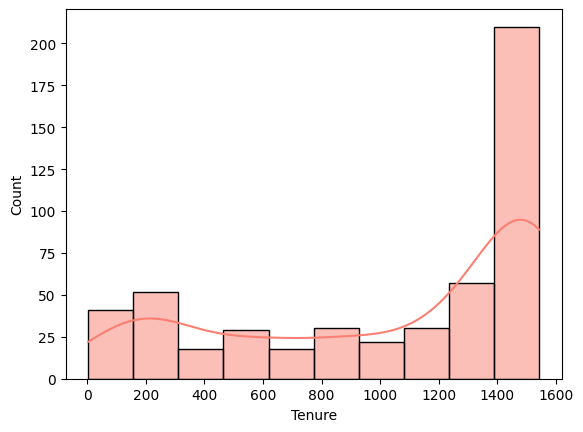

In [20]:
sns.histplot(data=df_tenure, x='Tenure', color='salmon', kde=True)

AFTER TENURE THEN RECENCY

In [21]:
df_recency = df_prep.groupby('CustomerID')['Date'].max().reset_index()
df_recency.columns = ['CustomerID', 'MaxPurchaseDate']
df_recency.head()

,CustomerID,MaxPurchaseDate
0,0,2023-03-18
1,1,2021-03-20
2,2,2023-02-01
3,3,2021-07-08
4,4,2022-12-23


Take The Data From The Latest Purchase For Every Customer ID With Subtracting It From The Latest Date Existed In The Dataset.

In [22]:
df_recency['Recency'] = (df_recency['MaxPurchaseDate'].max() - df_recency['MaxPurchaseDate']).dt.days
df_recency.head()

,CustomerID,MaxPurchaseDate,Recency
0,0,2023-03-18,7
1,1,2021-03-20,735
2,2,2023-02-01,52
3,3,2021-07-08,625
4,4,2022-12-23,92


<Axes: xlabel='Recency', ylabel='Count'>

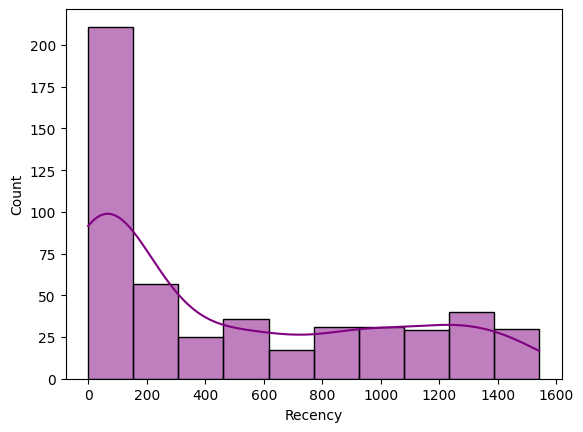

In [23]:
sns.histplot(data=df_recency, x='Recency', color='purple', kde=True)

AFTER RECENCY THEN FREQUENCY

In [24]:
df_frequency = df_prep.groupby('CustomerID')['Date'].count().reset_index()
df_frequency.rename(columns={'CustomerID':'CustomerID','Date':'Frequency'}, inplace=True,)
df_frequency.head()

,CustomerID,Frequency
0,0,51
1,1,13
2,2,36
3,3,1
4,4,38


In [25]:
import matplotlib.pyplot as plt

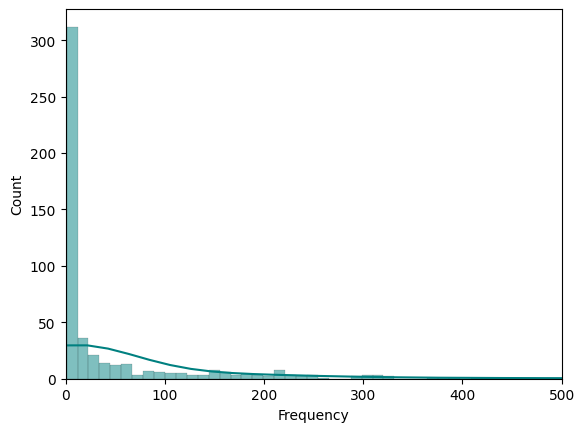

In [26]:
sns.histplot(data=df_frequency, x='Frequency', color='teal', kde=True)
plt.xlim(0, 500)
plt.show()

AFTER FREQUENCY THEN MONETARY

1. First, Need To Get Total Price By Multiple TotalSales * Quantity 

In [27]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29103 entries, 0 to 29102
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        29103 non-null  datetime64[ns]
 1   TotalSales  29103 non-null  float64       
 2   Discount    29103 non-null  float64       
 3   CustomerID  29103 non-null  int64         
 4   Quantity    29103 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 1.1 MB


In [28]:
df_prep['TotalSales'] = round((df_prep['TotalSales']), 2)
df_prep['Discount'] = round((df_prep['Discount']), 2)

In [29]:
df_prep['Total_Price'] = df_prep['TotalSales'] * df_prep['Quantity']
df_prep.head()

,Date,TotalSales,Discount,CustomerID,Quantity,Total_Price
0,2019-12-27,796.61,143.39,185,4,3186.44
1,2019-12-27,355.93,64.07,185,2,711.86
2,2019-12-27,901.69,162.31,230,4,3606.76
3,2019-12-27,182.75,32.90,230,1,182.75
4,2019-12-27,780.10,140.42,230,4,3120.40


2. Get The Total Purchase For Each Customer

In [30]:
df_Monetary = df_prep.groupby('CustomerID')['Total_Price'].sum().reset_index()
df_Monetary.rename(columns={"CustomerID":"CustomerID","Total_Price":"Monetary"}, inplace=True)
df_Monetary.head()

,CustomerID,Monetary
0,0,1364803.26
1,1,173885.45
2,2,265631.36
3,3,300.85
4,4,164438.92


<Axes: xlabel='Monetary', ylabel='Count'>

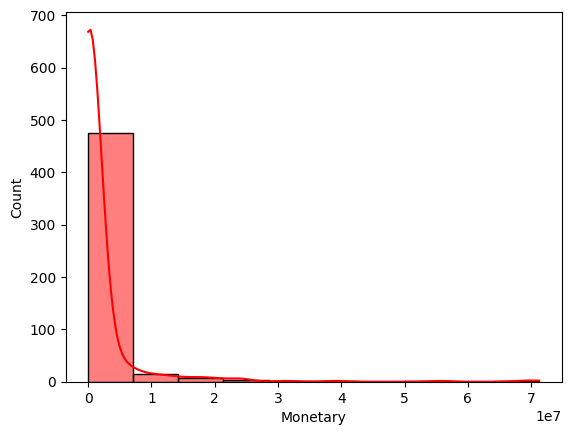

In [31]:
sns.histplot(data=df_Monetary, x='Monetary', kde=True, color='red', bins=10)



MERGING THE DATAS WHICH SEPARATED BEFORE FOR INFORMATION ABOUT RFM-T INTO ONE FILE.

1. Merging Here 

In [32]:
df_customer = pd.merge(df_customer, df_recency, on='CustomerID', how='inner')
df_customer = pd.merge(df_customer, df_tenure, on='CustomerID', how='inner')
df_customer = pd.merge(df_customer, df_frequency, on='CustomerID', how='inner')
df_customer = pd.merge(df_customer, df_Monetary, on='CustomerID', how='inner')


2. We Need To Drop MaxPurchaseDate And MinPurchaseDate Since We Dont Need Both Of Them For Further Analysis.

In [33]:
df_customer.drop(columns=['MinPurchaseDate', 'MaxPurchaseDate'], axis=1, inplace=True)

In [34]:
df_customer.head()

,CustomerID,Recency,Tenure,Frequency,Monetary
0,185,0,1542,301,6427190.27
1,230,0,1543,4153,31188530.22
2,458,8,1538,185,19300336.14
3,267,1180,1538,46,167009.78
4,424,5,1538,627,3908247.65


TIME FOR MODELING

1. Need Install !pip install lifetimes

BG/NBD MODEL WORKS FOR CUSTOMERS WITH NON ZERO-VARIABLES (Beta Geometric / Negative Binomial Distribution.)

This is a probability model used to predict future customer purchasing behavior in non-contract businesses (such as retail, online stores) where we do not know for sure when customers will churn. Frequency variable or number of repeat transactions. This model cannot predict the behavior of customers who only have a single transaction (frequency = 0) during the observation period.

------------------------------------------------

REASONS : 

1. Dropout Model Assumptions: A key assumption of the BG/NBD model is that a customer can only “drop out” (drop out) once they have made a purchase.

2. Lack of Behavioral Data: If a customer only makes one purchase (zero repeat purchase frequency), the model doesn't have enough data to distinguish between two scenarios:

- The customer is a very infrequent buyer who will return later.

- The customer is a one-time buyer who "dies" after the first transaction.

3. Unrealistic Probability: For a customer with a zero frequency, the model will automatically predict a 100% probability that the customer is still "alive," because they haven't had a chance (a second transaction) to exit the buying cycle. This is an unrealistic prediction for all new customers.

4. Focus on Repetition: This model fundamentally focuses on modeling repeat purchase behavior.

-------------------------------------------------------


2. We Need To Filter Only df_customer That Higher Than 0 Frequency And 0 Recency

In [35]:
df_customer = df_customer[df_customer['Frequency'] > 0]
df_customer = df_customer[df_customer['Recency'] > 0]

In [36]:
from lifetimes import BetaGeoFitter

FYI :

- BetaGeoFitter = Class (object) from the lifetimes library that implements the BG/NBD algorithm.

- df_customer = DataFrame (data table) containing historical data for each customer.

- Frequency = The number of repeat transactions made by a customer. (Total number of purchases minus one).

- Tenure = Customer age; time elapsed from first purchase to the end of the observation period (in the same time units as Recency).

- penalizer_coef Coefficient = small regularization to prevent overfitting (model fits too well to training data so it is bad at predicting new data).


-------------------------------------------------

Usage Rules and Limitations Important rules and limitations when using this model:

1. FRT Data Format: Input data must be a customer summary (df_customer), not a list of individual transactions. The lifetimes library has a utility function (summary_data_from_transaction_data) to assist with this preparation.

2. Consistent Time Units: Recency and Tenure must be in the same time units (e.g., both in weeks, or both in days).

3. Exact Customers: This model is best suited for non-contractual (non-subscription) businesses where you don't know exactly when customers churn. Customers churn silently (they simply stop buying).

4. Model Assumptions: This model assumes that the data reflects stable purchasing behavior and that purchase and churn rates do not change drastically over time.

-------------------------------------------------

3. Modelling The Dataset Using BetaGeoFitter

In [37]:
Beta_geofitter = BetaGeoFitter(penalizer_coef=0.001)
Beta_geofitter.fit(frequency=df_customer['Frequency'], recency=df_customer['Recency'], T= df_customer['Tenure'])

<lifetimes.BetaGeoFitter: fitted with 490 subjects, a: 0.45, alpha: 0.02, b: 6.65, r: 0.15>

EXPLANATION : 

Regularization, especially L2 regularization (Ridge Regression) : 

1. If the model is too flexible and only learns unique patterns from your training data (which may be just noise or chance), its predictive performance on new data will be poor. This is called overfitting.

2. The penalizer_coef adds an additional cost to the model optimization function. The larger this coefficient, the stronger the 'penalty' imposed on the model parameters, forcing it to remain simple and more general (less 'fit' to the specific training data).

Goal: Prevent overfitting.

How it works:

- Keep model parameters small and reasonable.

- Small value (e.g., 0.001): Mild penalty. The model is allowed to become slightly more complex.

- Large value (e.g., 1.0): Severe penalty. The model is forced to be very simple, which risks underfitting (the model is too simple to capture the true patterns in the data).

- The number 0.001 is a default value or starting point commonly used in many machine learning libraries.

- There is no single "magic number" that is always correct. The optimal value for penalizer_coef depends heavily on the volume and characteristics of your data.

- Commonly tried values ​​are typically in the range [0.001, 0.01, 0.1, 1.0].

- If you have very large and diverse data sets, you may not need a penalty at all (penalizer_coef=0.0).
- If your data is sparse or very noisy, you may need a higher penalty.


---------------------------------------------------------

HOW TO INTERPRETE :

- Transaction The transaction rate of each customer is constant as long as they are active, but varies between customers (following a Gamma Distribution).(r, alpha).

- Churn (Dropout) After each transaction, there is a chance that a customer will permanently drop out. This churn probability varies between customers (following a Beta Distribution). (a, b)

-----------------------------------------------------------------

1. r  And alpha : Transaction Parameter (Gamma Distribution: r and alpha) This controls how often customers shop while they are active.

- r: 0.15 : Logical Interpretation: This is the "shape" parameter.

- A low r value (usually below 1) indicates heterogeneity (large variation) in purchasing rates. What this means for your business: There is a small group of customers who purchase very frequently, but the majority of customers tend to purchase infrequently. This is a common characteristic in many retail businesses.

- Rule: If r is high, all customers purchase with relatively equal frequency.

- (alpha: 0.02) : Logical Interpretation: This is a "scale" parameter that relates to the average time between transactions.

- What it means for your business: A very low alpha value indicates that, on average, the time between purchases is relatively short (perhaps days or weeks, depending on the timeframe of your data).

- Rule of thumb: The lower the alpha, the faster the average purchase cycle.

2. B. Churn/Dropout Parameters (Beta Distribution: a and b)
This controls how likely a customer is to become inactive after a certain purchase.

 (a: 0.45) :

- Logical Interpretation: The first "shape" parameter for churn probability.
What it means for your business: This value is relatively small, which correlates with a low overall churn probability.

(b: 6.65) :

- Logical Interpretation: The second "shape" parameter for churn probability.
What it means for your business: A significantly higher b value than a (6.65 vs. 0.45) is a good sign. This indicates that most customers have a very low probability of churn. Your customers are likely to remain active after making a purchase.

Rule:

- If a and b are equal, the probability of churn is even.

- If b is much greater than a (as in your case), your customer base is relatively "loyal" or has a long lifetime.

- If a is much greater than b, most customers churn immediately after their first or second purchase.
 

-------------------------------------------------------


4. Now, We Can Predict The Frequency For Each Customer In The Next 6 Months

This model now serves as a prediction engine that you can use to answer specific questions about the future.

In [38]:
t = 180 # THE NUMBER OF DAYS IN 6 MONTHS
df_customer['Frequency_Predict_6Months'] = Beta_geofitter.conditional_expected_number_of_purchases_up_to_time(t=t, frequency=df_customer['Frequency'], recency=df_customer['Recency'], T=df_customer['Tenure'])
df_customer.tail(10)

,CustomerID,Recency,Tenure,Frequency,Monetary,Frequency_Predict_6Months
497,493,19,19,1,12203.40,7.512989
498,271,14,14,2,25579.68,16.788956
499,328,14,14,4,51292.35,29.999089
500,417,44,44,1,30508.48,3.705846
501,41,39,39,1,21694.92,4.115368
502,480,8,8,3,108813.62,35.098828
503,144,3,3,1,44789.19,29.377267
504,64,36,36,1,3197.90,4.409180
505,31,74,74,1,14284.76,2.331804
506,221,72,72,1,23647.44,2.390487


5. Visualize It With Lifetime Library

In [39]:
from lifetimes.plotting import plot_frequency_recency_matrix


c:\Users\m s i\AppData\Local\Programs\Python\Python313\Lib\site-packages\lifetimes\fitters\beta_geo_fitter.py:256: RuntimeWarning: overflow encountered in scalar power
  denominator = 1 + (x > 0) * (a / (b + x - 1)) * ((alpha + T) / (alpha + recency)) ** (r + x)


<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

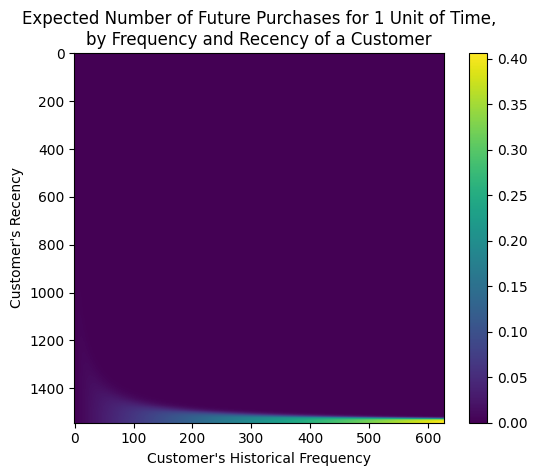

In [40]:
plot_frequency_recency_matrix(Beta_geofitter)

🔮 Expected number of future purchases
= estimated number of future transactions
in 1 unit of time (e.g., 1 week / 1 month, depending on your data settings).

"Estimate the number of future purchases within a given time period, based on:

- how often they buy (frequency)

- how recently their last transaction was (recency)"

---------------------------------------------------------

🧭 Graph Axes
X-axis: Customer's Historical Frequency

Meaning: How often a customer has purchased in the past.

Example:

- 1 = purchased once

- 10 = purchased 10 times

- 100 = very active customer

- 600 = super loyal customer

➡️ The further to the right = the more frequent purchases

--------------------------------------------------

Y-axis: Customer's Recency

Meaning: How long it's been since the last transaction. Usually in days (depending on your preprocessing).

Logical example:

- Low Recency = Just purchased yesterday

- High Recency = Long time since purchase

⚠️ Important note:
In your chart, the Y-axis is inverted:

- top = low recency (recent purchase)

- bottom = high recency (long-term non-purchase)

------------------------------------------------------

🎨 Color (Color Scale 0.00 – 0.40)

This is the most important part:

What is the 0.00 – 0.40 scale?

It stands for: Expected future purchases (average predicted transactions) per unit of time.

This means:

- 0.00 → almost never buy again

- 0.10 → average 0.1 transactions per period

- 0.40 → average 0.4 transactions per period

If 1 unit of time = 1 month:

- 0.40 ≈ 1 transaction every 2.5 months

- 0.10 ≈ 1 transaction every 10 months

- 0.01 ≈ almost dead (implicit churn)

-----------------------------------------------------

🧠 Core Logic of the Model (KEY UNDERSTANDING)

This model uses two basic assumptions:

1️⃣ Frequency logic: People who have purchased frequently in the past are more likely to purchase again.

2️⃣ Recency logic: People who have recently purchased are more likely to purchase again.
People who have not purchased in a long time are less likely to purchase again.

--------------------------------------------------------

🔑 How to Read the Heatmap

Imagine the grid as customer types:



🟩 Top Right (High Frequency + Low Recency)

Meaning:

- frequent buyers

- recent buyers

➡️ Golden customers

➡️ High CLV

➡️ Retention priority

➡️ Bright colors

-------------------------------------------------------------------

🟨 Bottom right (High Frequency + High Recency)

Meaning:

- used to buy frequently

- but haven't bought in a while

➡️ Dormant loyal customers

➡️ High risk of churn

➡️ Targeted reactivation campaign

➡️ Still has value

--------------------------------------------------------------


🟦 Top left (Low Frequency + Low Recency)

Meaning:

- rarely buys

- but recently bought

➡️ New customers

➡️ Growth potential

➡️ Focus on onboarding

-----------------------------------------------------------------------------


🟪 Bottom left (Low Frequency + High Recency)

Meaning:

- rarely buys

- hasn't bought in a while

➡️ Low value customers

➡️ Low CLV

➡️ Not a retention priority

➡️ Dark color (0.00)


----------------------------------------------------------------

📐 Reading Rules (Rules) Keep these as mental rules:

- ➡️ The further to the right → the more valuable
- ⬆️ The further up → the more active
- 🎨 The brighter → the higher the probability of repurchasing
- 🟣 The darker → implicit churn

------------------------------------------------------------

The basic formula (very simple):
Expected time per transaction = 1 / expected transactions per period. Or:

- Average time between transactions = 1 ÷ 0.40

- ✏️ Calculation:
1 ÷ 0.40 = 2.5

- ➡️ This means: 1 transaction every ±2.5 units of time.

If you: calculate recency & T in months
→ then 1 unit time = 1 month

BG/NBD models:

- The purchasing process is a Poisson process with rate (λ) = expected transactions per unit time

- In a Poisson process:

- Expected waiting time between events = 1 / λ



---------------------------------------------------------

FYI : 

Objective :

The objective is to map all possible customer profiles (combinations of Frequency and Recency) and display the model's predictions at each point. Colors are used to indicate "heat value," or future purchase expectations:

- Light Yellow/Green: High purchase expectations.

- Dark Purple: Low purchase expectations (customer likely to have churned).


-------------------------------------------------------------

HOW TO INTERPRETE :

Logic and Interpretation of Your Image :

Your image pattern is a typical result for a BG/NBD model trained on your data, which has a very long Tenure (around 1500 days) and a relatively short average time between purchases (alpha: 0.02).


Here's how to interpret it:

- X-axis (Customer's Historical Frequency): How often a customer purchases again.

- Y-axis (Customer's Recency): How recently their last purchase was (in units of time equal to 1500 days).

Patterns in your image:

1. Large Dark Purple Area (Majority of Plot): The model predicts that most frequency/recency combinations will result in very low (near zero) future purchases. This is because your data is very old (reaching 1400 days on the Y-axis).

- Yellow "Tail" on the Bottom Right: This is the interesting area.

- Customers here have High Frequency (X-axis to the right) AND High Recurrence (Y-axis down, meaning they've been customers for a long time).

- The BG/NBD model naturally expects customers who have been active for a long time and frequently purchase to continue purchasing. This tail represents the highest purchase expectation value for this customer segment.

2. Yellow Area on the Bottom Left: New customers who have recently purchased (Low reviews) are automatically considered active and have the potential to purchase in the future, which is why the bottom of the plot is not completely purple.

Interpretation Rules and Keys to Understanding :

- Key Insight: The most valuable customers are those in the bottom right quadrant (frequent and recent purchasers). Customers in the top right (frequent purchasers in the past but who have long since disappeared) are most likely to have churned.

- Usage Rules: You use this plot to visually confirm that your model behaves as business sense would suggest. Your model predicts a value of 0 for most long-term churn scenarios, which is logical for your data.

--------------------------------------------------------------------------------



  
  
  
  denominator = 1 + (x > 0) * (a / (b + x - 1)) * ((alpha + T) / (alpha + recency)) ** (r + x)


  This formula is the denominator in a larger equation, and its entire purpose is to adjust the prediction based on the model's confidence about whether the customer is alive (active) or has churned (dead).

 Purpose and Logic :

- The purpose of this formula is to calculate the probability fraction that represents a customer's "alive" status.

- The basic logic is: "The larger the value of this denominator, the lower the expected number of future purchases, because the probability of that customer remaining active is considered very low." This is how the model mathematically penalizes predictions if the data indicates churn behavior.

--------------------------------------------------------------------

Logical Explanation Formula Section :

- (1 + ...) This ensures the divisor is never zero and sets a base point for the calculation. Key variable N/A

- (x > 0) * x is the frequency. This part serves as a logical flag: if the frequency is 0 (only 1 purchase), the next part is ignored, and the calculation becomes simpler. Key Variable frequency (x)

- (a / (b + x - 1)) This is the ratio of the Beta distribution parameters (a and b) that govern the probability of churn. It compares the general tendency to churn with how often these customers actually purchase. Key Variables a, b.

- ((alpha + T) / (alpha + recency)) ** (r + x) This is the most important component that causes your prediction to be close to zero previously. It compares the Total Age (T) of the customer with the Age at Last Purchase (recency). Key Variables alpha, T, recency, r, frequency (x)

The Rules and How They Work in Your Case, The main rule in this formula is how it reacts to your data:

- If recency is close to T (Customers have recently purchased relative to their age):

1. The ratio (alpha + T) / (alpha + recency) approaches 1. The exponent becomes small.

2. The denominator remains small, resulting in high expectations of future purchases (customers are considered active).

- If recency is much smaller than T (Customers have not purchased in a while, but have been customers for a long time):

1. The ratio (alpha + T) / (alpha + recency) becomes a number much larger than 1.

2. When this number is raised to the power (r + x) (which can be large if the frequency is high, such as 185, 499, or 627 in your data), the result becomes very large.

3. The denominator becomes a very large number. Because this is a divisor in a larger formula, the end result (expected purchase) is close to zero (the model assumes churn).

- This is why you see the value 0.000000e+00 above. This formula effectively assigns a mathematical "dead" status to inactive customers.


------------------------------------------------------------------

In [41]:
from lifetimes.plotting import plot_probability_alive_matrix

--------------------------------------------------

This plots: The probability that a customer is still “alive” (active)
based on Frequency and Recency

- ⚠️ “Alive” here does NOT mean literally alive/dead
But:

- Still has the potential to make transactions in the future

-------------------------------------------------------

🧩 IMPORTANT concepts before reading the graph. BG/NBD has core assumptions:

- Every customer has a probability of dropping out (churn),
and once they churn, they will never buy again.

- This model doesn't wait for an explicit churn label,
but infers churn from transaction patterns.


<Axes: title={'center': 'Probability Customer is Alive,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

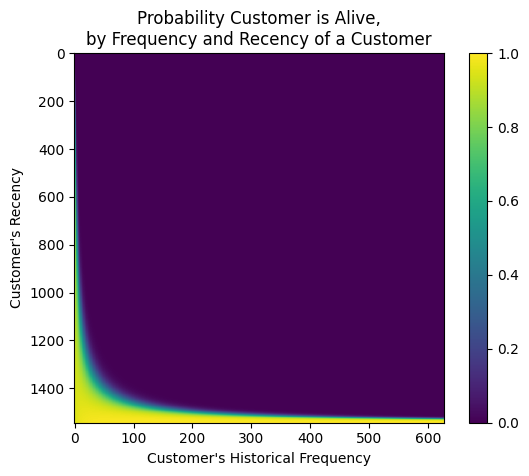

In [42]:
plot_probability_alive_matrix(Beta_geofitter)

-------------------------------------------------------------------

🧭 Graph Axes Meaning 

1. X-axis: Customer's Historical Frequency

How many times a customer has purchased in the past:

- Left → rarely purchases

- Right → frequently purchases

2. Y-axis: Customer's Recency. Time since last transaction

- Top → recently purchased

- Bottom → long time since purchase
(this axis is reversed, same as the previous graph)

| Value | Meaning |
| ----- | -------------------------------- |
| 1.0 | Almost certainly still active |
| 0.5 | Half likely still active |
| 0.0 | Almost certainly churned |


🔑 Key Understanding (THIS IS MOST IMPORTANT):

- Customer churn is not observed directly, but inferred from how often and how long ago they last purchased.

- The model asks: "With this pattern, does it make sense for this customer to still be active?"

--------------------------------------------------------

🧠 How to Read a Heatmap (step-by-step):

Imagine you select a point on the graph.

- Example 1: Top right (High Frequency + Low Recency)

Meaning:

A. frequent purchase

B. recent purchase

- ➡️ Probability of being alive is close to 1

- ➡️ Very active customer

- ➡️ Almost impossible to churn

---------------------------------------------------------

Example 2: Bottom right (High Frequency + High Recency)

Meaning:

A. Used to buy frequently

B. But hasn't bought in a long time

- ➡️ Probability of staying alive decreases

- ➡️ High-value customer but at risk

- ➡️ Primary reactivation target


--------------------------------------------------------

Example 3: Top left (Low Frequency + Low Recency)

Meaning:

A. rarely buys

B. but recently bought

- ➡️ Medium probability of survival

- ➡️ New customer

- ➡️ Still unclear whether loyal or not

--------------------------------------------------------

Example 4: Bottom left (Low Frequency + High Recency)

Meaning:

A. rarely purchases

B. hasn't purchased in a long time

- ➡️ Probability of being alive ≈ 0

- ➡️ Almost certain to churn

- ➡️ Don't prioritize retention

----------------------------------------------------------

📐 Rules of Thumb: Save this as a “rule of thumb”:

- 1️⃣ The more you buy → the greater your chance of survival.

- 2️⃣ The longer you don't buy → the lower your chance of survival.

- 3️⃣ High frequency can “save” poor recency.

- 4️⃣ Low frequency + poor recency = almost certain churn.

--------------------------------------------------------

🧮 A little math (to make it valid, but not difficult)

BG/NBD estimates:

1. Transaction rate (λ) → how often customers purchase

2. Dropout rate (μ) → how fast they churn

The probability of being alive is approximately:

- P(alive | history) : the probability that a customer hasn't dropped out

Without the long formula:

- If you haven't purchased in a long time → the probability of dropping out increases

- If you purchase frequently → dropout is considered small

-----------------------------------------------------------







🔗 Relationship with the previous graph (THIS IS IMPORTANT)

Chart 1:

1. Expected Future Purchases: If still alive, how often will they purchase?

2. Chart 2 (this): Probability of Alive: Still alive or has they churned?

And CLV:

CLV = Probability of Alive
× Expected Future Transactions
× Monetary Value


⚠️ So: Low probability of survival → automatically low CLV, Even though monetary value was high in the past.

---------------------------------------------------------------------

ASSESING MODEL FIT

In [43]:
from lifetimes.plotting import plot_period_transactions

<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

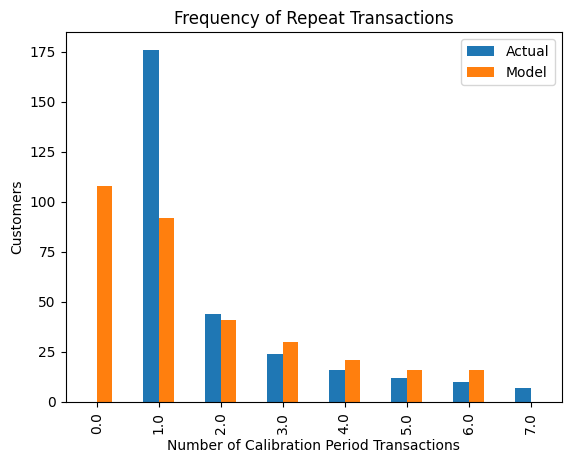

In [44]:
plot_period_transactions(Beta_geofitter)

---------------------------------------------------------------------------

Meaning:

- Comparison of actual customer transaction patterns
vs. transaction patterns predicted by the BG/NBD model

- ⚠️ This is not a CLV chart, not segmentation, not direct business insight.

This is:

- 🧪 Model diagnostic / model validation


----------------------------------------------------------------------------

🎯 Purpose & Function of This Graph (THIS IS THE KEY):

To check whether the BG/NBD model is "learning the data pattern correctly."

Questions answered by this graph:

1. Does the model:

- understand that most customers buy only once?

- understand that the more repeat purchases, the less frequent they are?

2. Is the predicted distribution similar to the original data?

- If it is similar, the model is suitable for use.

- If it is far from it, your CLV cannot be trusted.

-----------------------------------------------------------------------------


🧭 Graph Axes Meaning: 


1. X-axis: Number of Calibration Period Transactions

Meaning: The number of transactions made by a customer during the calibration (training) period.

Example:

- 0 → customer doesn't repeat the transaction at all

- 1 → repeats the transaction once

- 2 → repeats the transaction twice

- 7 → repeats the transaction seven times

2. Y-axis: Number of Customers

Meaning:

The number of customers who have made that number of transactions.


| Color | Meaning |
| -------------- | ------------------------------- |
| Blue (Actual) | Original transaction data |
| Orange (Model) | Predicted distribution of BG/NBD |





----------------------------------------------------------------------------

Then We Can Predict Now ABout The Monetary Spending For Each Customer In The Next 6 Months. We Will Use The Gamma-Gamma Model using The GammaGammaFitter Library

---------------------------------------------------------

🧠 How to Read a Graph (Step-by-Step):

A. Step 1: Focus on the shape, not the precise numbers

- This is not an exact match graph.

- What to look for:

- General pattern

- Trend

- Distribution shape

B. Step 2: Observe the actual data pattern (blue)

Typically in retail:

- Many customers → 1 transaction

- Fewer → 2 transactions

- Very few → 5+ transactions

- ➡️ Right-skewed distribution

- ➡️ This is normal

C. Step 3: Compare with model predictions (orange)

Key question:

Does the model:

- increase with low trades?

- decrease with high trades?

- If yes, the model captures the underlying pattern.

-----------------------------------------------------------------


🔍 Interpretation of your graph (concrete) :

From your graph:

1. ✔️ GOOD stuff

2. The model follows the trend:

- Customer 1 has the most transactions

- Higher transactions → fewer customers

- Orange shape ≈ blue shape

- ➡️ The model is structurally OK

--------------------------------------------------------

⚠️ Things to note

Model:

- Slightly overestimates customers with 0 transactions

- Slightly underestimates customers with 1 transaction

 At high transactions (5–7):

- Model is somewhat smooth

- Original data is noisier

- ➡️ This is normal, because:

- BG/NBD is a probabilistic model

- Extreme behavior is difficult to learn

--------------------------------------------------------

🧠 Key Understanding (this is important to remember):

- The model doesn't need to be perfect at every point.

- The model needs to be "distributionally similar."

If you force the bars to be exactly the same

→ the model overfits

→ CLV becomes dangerous

If the model\fails to capture repeat transactions:

- → expected purchases are incorrect → CLV is incorrect

- This graph = CLV quality control.


----------------------------------------------------------------

Gamma-Gamma Model Works If There Is A Low Correlation Between F And M

In [45]:
df_customer[['Frequency', 'Monetary']].corr()

,Frequency,Monetary
Frequency,1.000000,0.667602
Monetary,0.667602,1.000000


--------------------------------------------------------------------------

What's the big problem with CLV that often goes unnoticed?

Classic CLV (BG/NBD + Gamma-Gamma) has an important assumption:

- ⚠️ Frequency and Monetary Value MUST be relatively independent

This means:

- How often a customer buys should not significantly determine the value of their purchases

- If this assumption is violated, CLV will be biased

Real goal:

- Testing whether we CAN use the Gamma-Gamma model for monetary value

- This is not just EDA.

---------------------------------------------------------------------------------------

What does the number 0.667602 mean? It's the Pearson correlation coefficient.

Range:

- -1 → perfect negative correlation

- 0 → no linear relationship

- +1 → perfect positive correlation

Your number:

- corr(Frequency, Monetary) = 0.6676

Meaning:

- A fairly strong positive relationship


➡️ Customers who buy frequently → tend to spend more.


Why is this a problem with CLV?

- Because the Gamma-Gamma Model assumes:

- Monetary value is independent of frequency

Ideally:

- corr ≈ 0.0 – 0.3 → safe

- corr > 0.5 → ⚠️ caution

With 0.667:

- model assumptions violated

- CLV potentially overestimates high-frequency customers.

Pragmatically, in practice, many retail datasets do violate the assumptions but the model is still used with interpretation notes.

----------------------------------------------------------------

Plot period transactions:

1. “Does the transaction model capture repeat behavior patterns?”

2. Correlation Frequency–Monetary:

3. “Is the monetary model reliable?”

Both:

- Quality check before CLV

- If one fails:

- CLV can still be calculated

- but must be accompanied by caveats.

----------------------------------------------------------------

| Correlation | Interpretation |
| -------- | -------------------------- |
| < 0.3 | Safe for Gamma-Gamma |
| 0.3–0.5 | Still possible, but be careful |
| > 0.5 | ⚠️ Assumption violated |

-----------------------------------------------------------------

Relationship to CLV Formula (to make it more consistent)

Rough CLV:

- CLV = Expected Transactions × Expected Monetary Value

If:

1. Expected Transactions ↑

2. Expected Monetary Value also ↑ due to correlation

→ CLV can double-count loyalty

That's why this correlation is checked.

🧠 Super simple version (common sense)

Imagine:

- Customers come frequently

- Always spend big

If you do the math:

- “comes frequently” × “spend big”
without checking the correlation

- ➡️ you're counting loyalty twice

----------------------------------------------------------



Train The Model Gama-Gama Model

In [46]:
from lifetimes import GammaGammaFitter

In [47]:
GammaFitter = GammaGammaFitter(penalizer_coef=0.01)
GammaFitter.fit(frequency=df_customer['Frequency'], monetary_value=df_customer['Monetary'])

<lifetimes.GammaGammaFitter: fitted with 490 subjects, p: 2.48, q: 0.11, v: 2.38>

----------------------------------------

Building a model to estimate the average spending value per customer transaction in the future.

⚠️ Important:

- This is NOT CLV

- This is a component of CLV


CLV = Expected Future Transactions (BG/NBD)
      × Expected Monetary Value (Gamma-Gamma)

So: BG/NBD → how many times a customer will buy

- Gamma-Gamma → how much each transaction will cost

The Method has already confirmed:

- the transaction model makes sense (plot_period_transactions)

- then build the monetary model

- This is the CORRECT order.

------------------------------------------------------------------------------

Gamma-Gamma answers one business question:

"If this customer is still active, what is their average purchase value per transaction?"

This model:

- doesn't care when they buy

- doesn't care how many times in the future

- focuses only on transaction value.

Why are the inputs only frequency and monetary? Because the model assumes:

- Customers have a true average spend, but what we see is only a sampling of past transactions.

- Logically:

- Customers who only buy once → average spend is unstable.

- Multiple purchases → more confident estimates.

- Frequency is used as a confidence weight,
not because frequency determines monetary value (remember the correlation above ⚠️).

What does penalizer_coef=0.01 mean? This is regularization.

Goal:

- Prevent "wild" parameters

- Make the model more stable

Rule of thumb:

- 0.0 → No penalty (risky if the data is noisy)

- 0.01 → Safe & common

- 0.1 → Too rigid

Choosing a conservative value → Good practice.

--------------------------------------------------------



Now… how to read this output 👇

<lifetimes.GammaGammaFitter:

fitted with 490 subjects,

a. p: 2.48,

b. q: 0.11,

c. v: 2.38>

Fitted with 490 subjects :

This means 490 customers are used to train the model.

Usually, only customers with:

- Frequency > 0

- Monetary > 0

- One-time buyers are often excluded.

➡️ This is normal and correct.

--------------------------------------------------

These are parameters of the Gamma-Gamma distribution, not a direct business KPI. Here's how to think about it:

The model assumes:

- Each customer has a latent average spend

- This latent spend follows a Gamma distribution

Intuitive meaning:

- p & q → shape of the customer spending distribution

- v → variation across customers

- You don't need to interpret these numbers individually in your business reports.

Important:

The model is convergent and stable.

--------------------------------------------

- p = 2.48 OK,

- q = 0.11 is small but valid,

- v = 2.38 OK”

❌ NOT because:

- there's a magic table

- there's an ISO rule

- there's a universal ideal number

✅ BUT because of these 5 rules of reasoning:

1. RULE 1 — Does the model make mathematical sense?

Gamma-Gamma requires all parameters > 0

If:

- p ≤ 0 ❌

- q ≤ 0 ❌

- v ≤ 0 ❌

➡️ the model theoretically collapses. In your data:

- all positive. ✔️ meets the model's existence requirement

- This is a hard rule.

2. RULE #2 — Are the numbers “wild”? As an analyst, you develop an intuitive radar.

Example red flags:

- p = 0.00001

- q = 987

- v = 1200

These are usually signs of:

- problematic data

- overfitting

- severe outliers

Your numbers:

- 0.11, 2.48, 2.38

- ➡️ normal order of magnitude.

- ➡️ not extreme.

- ➡️ not explosive.

- ✔️ numerically stable

This isn't a formula—it's statistical sense.

3. RULE #3 — Does the model converge without error? This is important but often overlooked.

Fact: Many models fail to converge if the data assumptions are poor.

Your model:

- fits without error

- parameters are not NaN

- no severe warnings

➡️ means: “Mathematically, there is a consistent solution for this data.”

✔️ this is implicit validation.

4. RULE #4 — Are the model assumptions recognized (not ignored)? You are NOT blind to this:

corr(Frequency, Monetary) = 0.667

This means:

- The independence assumption is partially violated. This is where analyst maturity comes in.

- “Okay, the assumptions aren’t perfect → the results are directional estimates.”

- ➡️ The model isn’t wrong

- ➡️ BUT the interpretation is lowered in certainty

- This is why I said:

- “Technically valid, but interpretation must be cautious”

5. RULE #5 — Does the model answer a reasonable business question?
Gamma-Gamma Question:

- “If a customer buys again, what is their average purchase value?”

This is:

- relevant

- reasonable

- frequently used in industry

If the question is absurd:

- “What is the spiritual value of a customer?”

- then the model is nonsense.

➡️ The question is sound → the model is usable

-----------------------------------------------------------


NOW THE PHILOSOPHY:

“All models are wrong, some are useful.” — George Box

As an analyst:

- you are not looking for ontological truth

- you are looking for epistemological tools

- Gamma-Gamma is not “customer reality” but:

- a structured way of thinking about the uncertainty of shopping value.

--------------------------------------------------------



Now We Are Ready To Predict The CLV

-------------------------------------------------------------------------------------

👉 This is the final step in the entire probabilistic CLV pipeline.

To simplify it humanly:

- “How much money is this customer probabilistically expected to make in the next 6 months, based on their past patterns?”

Not:

- a definite prediction

- not a magic prophecy

- not a business promise

- ➡️ this is a mathematical expectation (expected value).

In [48]:
df_customer['Monetary_Predicted_6Months'] = GammaFitter.customer_lifetime_value(
    transaction_prediction_model=Beta_geofitter,
    frequency=df_customer['Frequency'],
    recency=df_customer['Recency'],
    T=df_customer['Tenure'],
    monetary_value=df_customer['Monetary'],
    time= 6, # Our Next 6 Months.
    freq='D', # Since Our Tenure Columns Is In Days Format.
    discount_rate= 0.01
)

-----------------------------------------

What's ACTUALLY being calculated behind the scenes?

The resulting CLV is a conceptual multiplication:

CLV ≈ (Expected Number of Future Transactions)
× (Expected Monetary Value per Transaction)
× (Discounting).

------------------------------------------------

More details:

1. 🧠 Component 1 — BetaGeoFitter

Answer:

“Is this customer alive or dead, and if so, how often will they buy?”

➡️ output: Frequency_Predict_6Months.


2. 🧠 Component 2 — GammaGammaFitter

Answer:

"If he buys again, what is the average transaction value?"

➡️ Output: Expected Monetary Value.

3. Component 3 — Discounting

Answer:

"Will money in 6 months be worth the same as money today?"

➡️ Output: Present Value.

----------------------------------------------------------------



"Why is there a DISCOUNT when the dataset doesn't have any discounts?" The discount rate does NOT come from the data.
The discount rate comes from financial theory.

What is a discount rate conceptually?

❌ Not:

- price cuts

- promotions

- vouchers

✅ But:

- Time Value of Money

- Basic economic principle:

- Money today is worth more than money in the future

Reasons:

- inflation

- risk

- opportunity cost

--------------------------------------------------------------------

Why MUST there be a discount in CLV?

Because CLV is: The Net Present Value of future cash flows.

Without a discount:

- CLV becomes too optimistic.

- Future customers are counted as equivalent to today's money.

- Unrealistic for business decisions.

That's why all serious CLV models always include a discount, even if the data doesn't mention it.

----------------------------------------------------------------------

So, where does the 0.01 figure come from? That's a business assumption, not a data estimate.

Typically:

- 0.01 → conservative

- 0.05 → aggressive

- depends on the industry context

📌 There is no "universal correct number"


-----------------------------------------------------------------------------------

The CLV model doesn't say: "Customer A will definitely earn Rp480,724."

The model says:

- "If reality repeats itself many times, this is the mathematical expectation value."

- This is probabilistic logic, not deterministic.

- And BI: not seeking certainty
but managing uncertainty rationally.

----------------------------------------------------------------------------------




Why Discounts Are IMPORTANT in CLV (not a formality):

CLV is used to:

- determine the marketing budget

- determine which customers to prioritize

- determine retention costs

If you don't use discounts:

- new customers will appear too valuable

- business could overspend

- ROI becomes an illusion

📌 So discounts protect business decisions
not beautify the numbers

NARRATION :

In CLV modeling, future customer transactions are not treated as equally valuable as transactions happening today. Although the nominal amount of money may be the same, money received in the future carries uncertainty and cannot be used immediately for operational or investment purposes. Therefore, a discount rate is applied to adjust future predicted cash flows into their present value. This does not reduce the accuracy of the prediction, but rather makes the estimated customer value more realistic and conservative for business decision-making.

By applying discounting, CLV reflects not only how much value a customer may generate, but also when that value is expected to be realized.

- Simple Illustration

Suppose a customer is predicted to generate $1,000 in transactions over the next 6 months. Although the amount is known, the business will only receive that money in the future, not today. Since the company cannot immediately use that money for operations, marketing, or reinvestment, its current value is considered slightly lower than $1,000. Discounting is applied to reflect this timing difference, ensuring that future revenue is evaluated fairly when compared to current costs and investments.

--------------------------------------------------------------------


IN A OTHER WORDS :

“Future revenue is valuable, but it is not the same as having cash today.”

OR 

"Discounting adjusts future predicted revenue to reflect that money received later is less immediately useful than money received today".

🔑 Discount Rate IS NOT:

- price cuts

- number manipulation

- model error correction

🔑 Discount Rate IS:

- recognition that time is of the essence

- a way to make predictions more realistic

- a tool to avoid overestimation

🔑 Core Principle (One Sentence):

The same amount of money has different practical value depending on when it is received.

---------------------------------------------------------------------


Our Final Predicted CLV Data

In [49]:
df_customer.head()

,CustomerID,Recency,Tenure,Frequency,Monetary,Frequency_Predict_6Months,Monetary_Predicted_6Months
2,458,8,1538,185,19300336.14,0.000000e+00,0.000000
3,267,1180,1538,46,167009.78,2.956200e-03,480.724156
4,424,5,1538,627,3908247.65,0.000000e+00,0.000000
5,420,3,1533,617,55606885.91,0.000000e+00,0.000000
6,492,165,1477,12,114884.74,1.558150e-10,0.000018


-----------------------------------------------------------------------

Now let's read your results one by one (this is important).

A. Example row:

- CustomerID: 458

- Frequency: 185

- Recency: 8

- Tenure: 1538

- Frequency_Predict_6Months: 0

- Monetary_Predicted_6Months: 0

❓ Why is it 0 even though the frequency is high?

This is a CRUCIAL point that often causes confusion. BG/NBD Logic:

It's not how often they purchased,
but how long it's been since their last purchase compared to the customer's lifespan.

This customer:

- Long tenure (1538 days)

- Very low recency (8 days since last purchase)

➡️ In the model:

- Very high probability of churn

- Expected transactions ≈ 0

Therefore:

CLV = (≈0 transactions) × (any monetary amount)
= 0

-📌 This is not an error

-📌 This is a logical consequence of the model's assumptions.

B. Another example:

- CustomerID: 267

- Frequency_Predict_6Months: 0.0029

- Monetary_Predicted_6Months: 480.72

This means mathematically:

“Out of 1,000 customers like this, approximately 3 transactions will occur within 6 months.”

➡️ CLV is small but not zero.



----------------------------------------------------------------------------

In [50]:
df_customer.to_csv('FinalPredictedDataCLV.csv', index=False)